<a href="https://colab.research.google.com/github/hidnira-lab/introduce-data-science/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Logistic Regression
- Muhammad Farhan Haafidh Abror (24523115)
- Hidayat Nur Hijrah (24523201)

In [ ]:
# Install library yang dibutuhkan
!pip install kagglehub[pandas-datasets] pandas scikit-learn matplotlib seaborn

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Load dataset Penyakit Jantung (Heart Failure) dari Kaggle
try:
    df = kagglehub.load_dataset(
      KaggleDatasetAdapter.PANDAS,
      "fedesoriano/heart-failure-prediction",
      "heart.csv"
    )
    print("Dataset berhasil dimuat!")
except Exception as e:
    # Alternatif URL jika Kagglehub error di Colab
    print("Menggunakan link alternatif...")
    df = pd.read_csv("https://raw.githubusercontent.com/fedesoriano/Heart-Failure-Prediction-Dataset/main/heart.csv")

# Tampilkan 5 data teratas
display(df.head())

/tmp/ipykernel_7927/746290825.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Dataset berhasil dimuat!


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Memisahkan Fitur (X) dan Target/Jawaban (y)
# Target kita adalah kolom 'HeartDisease' (1 = Sakit Jantung, 0 = Normal)
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Mengubah data teks (kategorikal) menjadi angka (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

print("Bentuk data fitur setelah preprocessing:", X.shape)
display(X.head())

Bentuk data fitur setelah preprocessing: (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% untuk belajar (training) dan 20% untuk ujian (testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

Jumlah data latih: 734
Jumlah data uji: 184


In [ ]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi model (max_iter ditambah agar model punya cukup waktu menemukan pola)
model = LogisticRegression(max_iter=2000)

# Melatih model dengan data training
model.fit(X_train, y_train)

# Meminta model menebak (prediksi) pada data testing
y_pred = model.predict(X_test)

print("Proses training dan prediksi selesai!")

Proses training dan prediksi selesai!


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



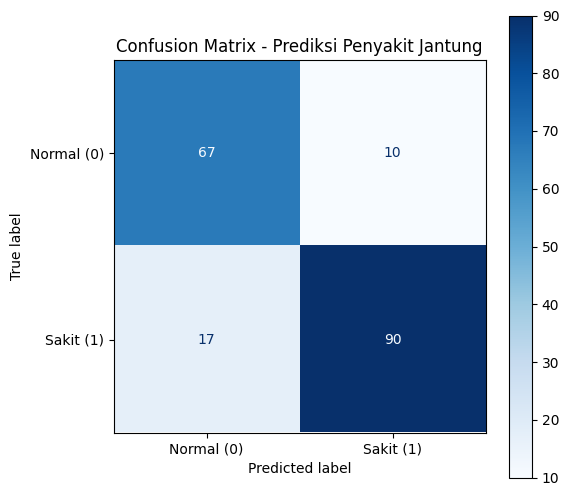


Beberapa contoh hasil prediksi vs kenyataan:


,Aktual (y_test),Prediksi (y_pred)
0,0,0
1,1,0
2,1,1
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Menampilkan Classification Report
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# 2. Membuat dan Menampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Sakit (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - Prediksi Penyakit Jantung")
plt.show()

# 3. Menampilkan contoh prediksi vs aktual (Syarat Tugas No. 5)
hasil = pd.DataFrame({
    'Aktual (y_test)': y_test.values,
    'Prediksi (y_pred)': y_pred
})
print("\nBeberapa contoh hasil prediksi vs kenyataan:")
display(hasil.head(10))

### Analisis Kinerja Model Logistic Regression

Berdasarkan Classification Report dan Confusion Matrix:

1.  **Classification Report**:
    *   **Akurasi (Accuracy)**: Model mencapai akurasi **85%**. Ini berarti 85% dari total prediksi (baik "Normal" maupun "Sakit Jantung") yang dibuat oleh model adalah benar.
    *   **Presisi (Precision)**:
        *   Untuk kelas `0` (Normal): 80% prediksi "Normal" adalah benar.
        *   Untuk kelas `1` (Sakit Jantung): 90% prediksi "Sakit Jantung" adalah benar. Ini menunjukkan bahwa ketika model memprediksi seseorang sakit jantung, kemungkinan besar prediksi itu benar.
    *   **Recall (Sensitivitas)**:
        *   Untuk kelas `0` (Normal): 87% dari pasien yang sebenarnya "Normal" berhasil diprediksi dengan benar.
        *   Untuk kelas `1` (Sakit Jantung): 84% dari pasien yang sebenarnya "Sakit Jantung" berhasil diprediksi dengan benar. Ini menunjukkan kemampuan model dalam mengidentifikasi kasus positif yang sebenarnya.
    *   **F1-Score**: Rata-rata harmonis dari Presisi dan Recall. Menunjukkan keseimbangan antara kedua metrik.

2.  **Confusion Matrix**:
    *   **True Positive (TP)**: **90** (Model memprediksi "Sakit Jantung" dan pasien memang "Sakit Jantung"). Ini adalah prediksi yang benar.
    *   **False Positive (FP)**: **10** (Model memprediksi "Sakit Jantung" padahal pasien "Normal"). Ini adalah kesalahan Tipe I.
    *   **True Negative (TN)**: **67** (Model memprediksi "Normal" dan pasien memang "Normal"). Ini adalah prediksi yang benar.
    *   **False Negative (FN)**: **17** (Model memprediksi "Normal" padahal pasien "Sakit Jantung"). Ini adalah kesalahan Tipe II, dan dalam konteks medis, ini bisa sangat berbahaya karena pasien yang sakit tidak terdeteksi.

### Kesimpulan
Model Logistic Regression ini bekerja cukup baik dengan akurasi 85%. Model menunjukkan presisi yang baik dalam memprediksi kelas "Sakit Jantung" (90%). Namun, jumlah **17 False Negatives** adalah perhatian utama. Ini berarti ada 17 pasien yang sebenarnya memiliki penyakit jantung tetapi diklasifikasikan sebagai normal oleh model. Dalam skenario medis, False Negatives seperti ini bisa berakibat fatal, sehingga perlu upaya lebih lanjut untuk mengurangi angka ini, mungkin dengan menggunakan model yang lebih kompleks atau teknik penanganan imbalance data jika ada.